# AlphaGenome Analysis of CRISPR-Validated Enhancers

This notebook automates the analysis of different variants using AlphaGenome. Input your personal API key file and variant file in the configuration section below, as well as assay types and cell line of interest. 

## Setup and Imports

In [12]:
# Standard library imports
import io
import itertools
import os

# Third-party imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import clear_output

# AlphaGenome imports
import alphagenome
from alphagenome import colab_utils
from alphagenome.data import gene_annotation
from alphagenome.data import genome
from alphagenome.data import track_data
from alphagenome.data import transcript as transcript_utils
from alphagenome.models import dna_client
from alphagenome.models import variant_scorers
from alphagenome.visualization import plot_components

# My helper functions
from helper_functions import *
import helper_functions

# Print AlphaGenome version
print(f"AlphaGenome version: {alphagenome.__version__}")

AlphaGenome version: 0.6.1


## Configuration Section

MODIFY THESE PARAMETERS FOR YOUR ANALYSIS

In [13]:
# Your API key in a text file
API_KEY_FILE = 'my_api_key.txt'

# Your variants of interest in a tab-delimited file
# See README for file type details
VARIANT_FILE = 'LTR10_variants.tab'

# Primary assay types to analyze (list multiple assays)
# Options: 'ATAC', 'CAGE', 'DNASE', 'RNA_SEQ', 'CHIP_HISTONE', 'CHIP_TF', 
#          'SPLICE_SITES', 'SPLICE_SITE_USAGE', 'SPLICE_JUNCTIONS', 'CONTACT_MAPS', 'PROCAP'

#PRIMARY_ASSAYS = ['CHIP_TF']
PRIMARY_ASSAYS = ['RNA_SEQ', 'ATAC','CHIP_HISTONE']

# Primary cell line to focus on
PRIMARY_CELL_LINE = 'HCT116' 
PRIMARY_CELL_LINE_ID = 'EFO:0002824' 

## Initialize AlphaGenome with API Key

In [14]:
# Read API key from file
with open(API_KEY_FILE, 'r') as f:
    API_KEY = f.read().strip()

# Initialize model
dna_model = dna_client.create(API_KEY)

## Load Gene Annotations

In [15]:
gtf = pd.read_feather(
    'https://storage.googleapis.com/alphagenome/reference/gencode/'
    'hg38/gencode.v46.annotation.gtf.gz.feather'
)

gtf_transcript = gene_annotation.filter_transcript_support_level(
    gene_annotation.filter_protein_coding(gtf), ['1']
)

gtf_longest_transcript = gene_annotation.filter_to_longest_transcript(
    gtf_transcript
)
longest_transcript_extractor = transcript_utils.TranscriptExtractor(
    gtf_longest_transcript
)

## Load Variants from Provided File

In [16]:
def load_variants(filepath=VARIANT_FILE) -> pd.DataFrame:
    """Returns a dataframe of variants from a tab-delimited file."""
    return pd.read_table(filepath, sep='\t', index_col=False)

def create_variant_from_row(row):
    """Convert a DataFrame row to a genome.Variant object."""
    return genome.Variant(
        chromosome=row['CHROM'],
        position=int(row['POS']),
        reference_bases=row['REF'],
        alternate_bases='',  # empty for deletion
        name=row['ID']
    )

variant_df = load_variants()
variant_df['Deletion_Length'] = variant_df['REF'].str.len()

# Display the dataframe
variant_df

,ID,CHROM,POS,REF,ALT,Output,Study_ID,Study_Variant_ID,Deletion_Length
0,LTR10.MEF2D,chr1,156398366,GGTTTCTCCATGTTGGTCAGGCTGGTCTGGAACTCCCCACATCAGG...,.,1,Ivancevic_2024,LTR10.MEF2D,500
1,LTR10.FGF2,chr4,122786290,TTAGATATGAGTTCTAAATTTCTTCTCAAAGAATCAATATGTCAGT...,.,1,Ivancevic_2024,LTR10.FGF2,500
2,LTR10.XRCC4,chr5,82969146,AAAAGTCAGCATGGAGACAAGTGATCTCACAACAAGGCCATCTTTA...,.,1,Ivancevic_2024,LTR10.XRCC4,8178
3,LTR10.ATG12,chr5,115928579,ATTTCAAAAGAGATTGAACTGCTGGACACAACTGACTGAGAGAAGA...,.,1,Ivancevic_2024,LTR10.ATG12,2358
4,LTR10.MCPH1,chr8,6648825,TAAGCTAATTCCAATTGGCTATTTTAAAGACAGCAGAGGTACAAGC...,.,1,Ivancevic_2024,LTR10.MCPH1,667
5,LTR10.KDM6A,chrX,45005876,AGTTCAGTCCCCTCCAATGGGCATGTCTCACCTCTTTTTAACCTGT...,.,1,Ivancevic_2024,LTR10.KDM6A,500
6,control_deletion_near_ATG12,chr5,115946791,CGTCATTACAGCTCAAGCCTGAGGTGGTGTGTATTGTGTGGTGGAC...,.,0,NaN,NaN,2358


## Set Global Variables

In [17]:
helper_functions.PRIMARY_ASSAYS = PRIMARY_ASSAYS
helper_functions.PRIMARY_CELL_LINE = PRIMARY_CELL_LINE
helper_functions.PRIMARY_CELL_LINE_ID = PRIMARY_CELL_LINE_ID
helper_functions.dna_model = dna_model
helper_functions.longest_transcript_extractor = longest_transcript_extractor
helper_functions.variant_df = variant_df
helper_functions.gtf = gtf

## Example Usage

In [18]:
# Main helper functions

help(plot_baseline)
print("="*80)

help(plot_deletion)
print("="*80)

help(plot_difference)
print("="*80)

help(score_deletion)
print("="*80)

help(plot_variant_effects_coord_scatterplot)
print("="*80)

Help on function plot_baseline in module helper_functions:

plot_baseline(variant_name, start=None, end=None)
    Plot baseline (reference) genome state for all selected assays.

    Args:
        variant_name: Variant ID (e.g., 'LTR10.ATG12')
        start: Custom start coordinate (default: variant_start - 5kb)
        end: Custom end coordinate (default: variant_end + 5kb)

Help on function plot_deletion in module helper_functions:

plot_deletion(variant_name, start=None, end=None)
    Plot genome state WITH deletion (mimics CRISPR knockout) for all selected assays.

    Args:
        variant_name: Variant ID (e.g., 'LTR10.ATG12')
        start: Custom start coordinate (default: variant_start - 5kb)
        end: Custom end coordinate (default: variant_end + 5kb)

Help on function plot_difference in module helper_functions:

plot_difference(variant_name, start=None, end=None)
    Plot the difference from baseline for all selected assays, e.g. the effect of the deletion.

    Positive 

In [19]:
# Other optional helper functions

help(plot_difference_corrected_rna)
print("="*80)

help(plot_overlaid_corrected_rna)
print("="*80)

help(score_deletion_alt)
print("="*80)

help(plot_variant_effects_ma)
print("="*80)

Help on function plot_difference_corrected_rna in module helper_functions:

plot_difference_corrected_rna(variant_name, start=None, end=None)
    Plot RNA-seq deletion effects with frameshift correction.

    Deletions cause a coordinate shift in predictions downstream of the variant.
    This creates visualization errors when the variant is not at the right edge of the plot.
    This function uses AlphaGenome's recommended padding approach to correct the alignment,
    but this method only really works for high-resolution tracks like RNA-seq.

    Args:
        variant_name: Variant ID (e.g., 'LTR10.ATG12')
        start: Custom start coordinate (default: variant_start - 5kb)
        end: Custom end coordinate (default: variant_end + 5kb)

Help on function plot_overlaid_corrected_rna in module helper_functions:

plot_overlaid_corrected_rna(variant_name, start=None, end=None)
    Plot reference vs deletion RNA-seq with frameshift correction (overlaid view).

    Same as plot_difference

## Example Usage
## Explore Variant: LTR10.ATG12

In [20]:
# TODO: update the helper function to use this plot baseline function instead
# Fixes the rasterization issue with Illustator where tracks just go missing 
# because they're made up of too many tiny parts. 
# likewise update all of the other browser plots

Creating baseline view for LTR10.ATG12
Making baseline predictions for ['RNA_SEQ', 'ATAC', 'CHIP_HISTONE']...


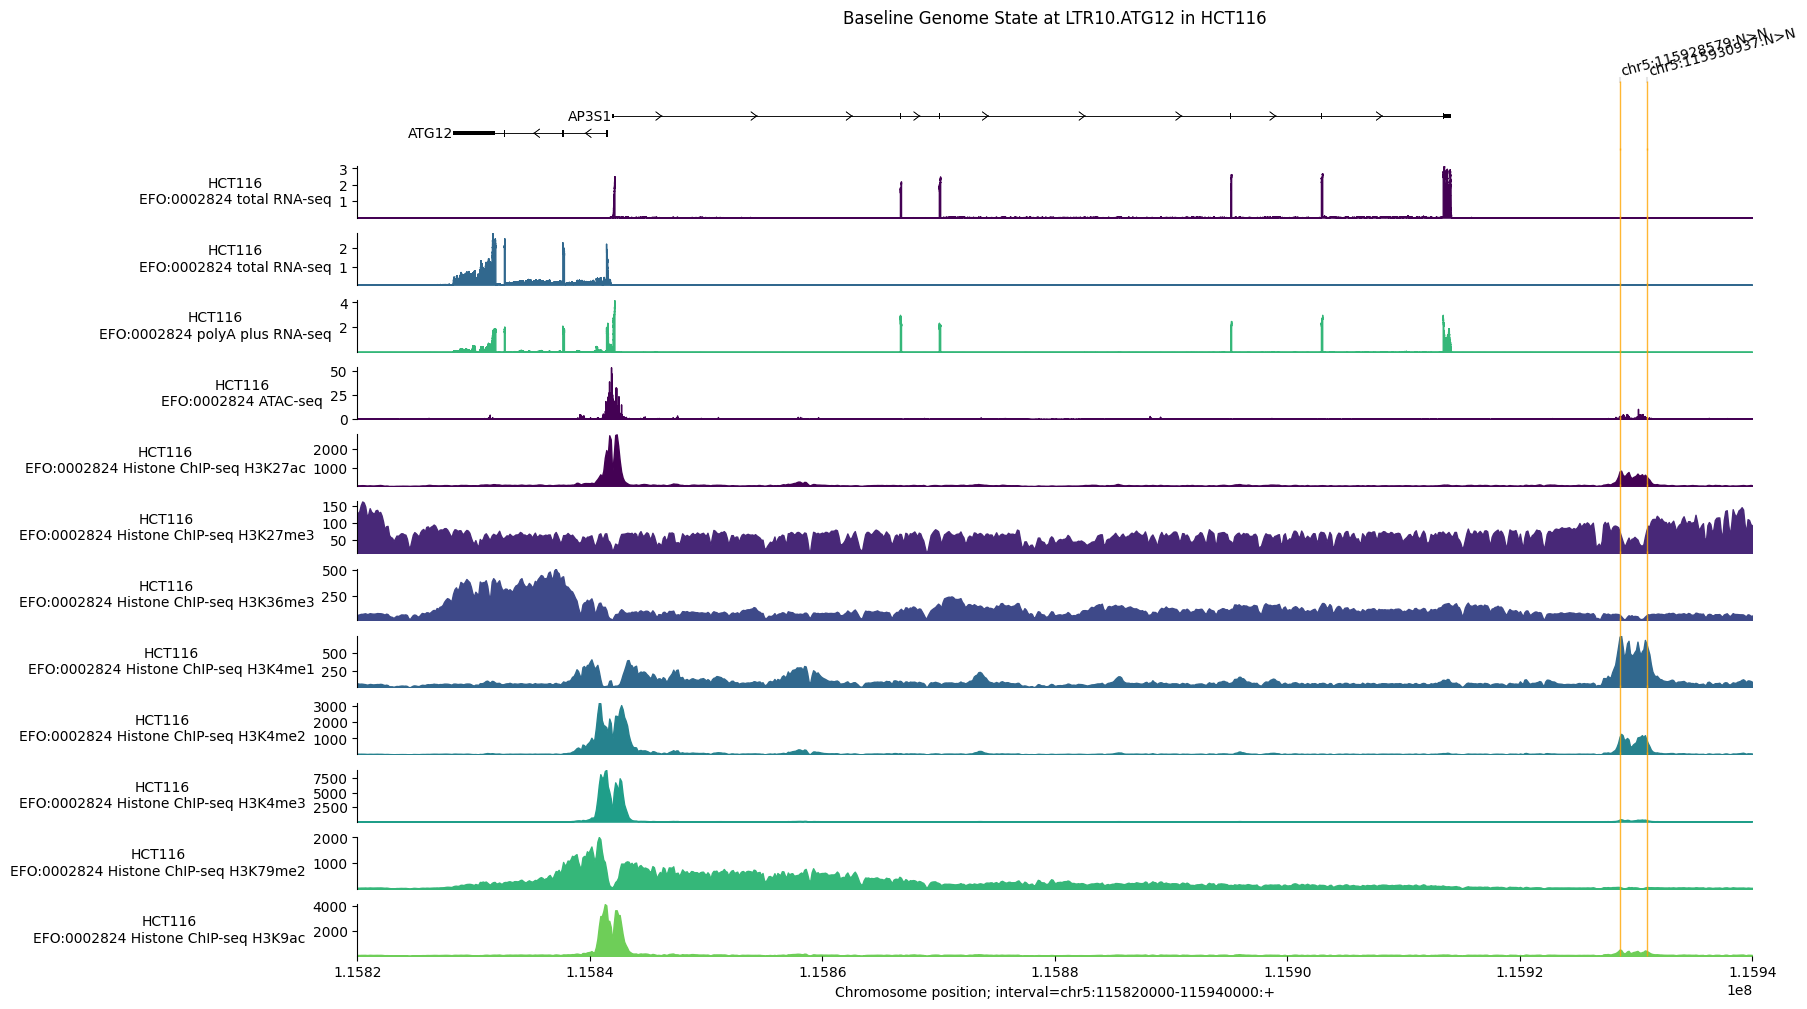

In [21]:
plot_baseline('LTR10.ATG12', 115820000, 115940000)

Scoring deletion effects for LTR10.ATG12
Location: chr5:115,928,579-115,930,937
Assay: RNA_SEQ
Running variant scoring...

RESULTS: 58 effects in HCT116
             count   mean
output_type              
RNA_SEQ         58 -0.083

 Saved results to: LTR10.ATG12_HCT116_deletion_scores_RNA_SEQ.csv
Using max absolute effect per gene: 58 predictions

=== Got 29 unique genes from scoring ===

=== Fetching TSS coordinates from GTF ===
Found 155104 GTF entries on chr5
Found TSS positions for 3076 unique genes in GTF
Filtered to protein_coding genes: 11/29 genes

=== Position matching results ===
Matched: 11/11 genes (100.0%)

=== Creating plot with 11 genes ===
Using manual x-axis limits: [111,250,000, 121,250,000]
Using manual y-axis limits: [-0.35, 0.35]

✓ Saved: LTR10.ATG12_HCT116_RNA_SEQ_max_effect_genomic_plot.pdf


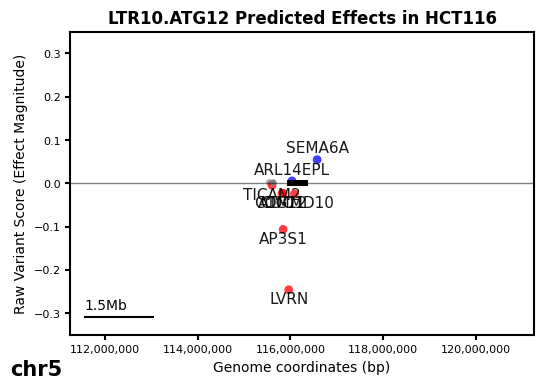

In [24]:
plot_variant_effects_coord_scatterplot('LTR10.ATG12', 
                                       track_filter='max_effect', 
                                       color_threshold=0.9, 
                                       gene_types='protein_coding', 
                                       xlim=[111_250_000, 121_250_000],
                                       ylim=[-0.35, 0.35]
                                      )